# Post-selected logical error curves

Simulate circuit noise, post-select syndromes, decode the shots, and plot logical error rate (LER) against rejection rate. Change the model name below to use any of the eight supplied models. To use a GPU, set `device = "cuda"` below; this needs PyTorch with CUDA support. Only the neural network runs on the GPU; BP and decoding stay on the CPU.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import mpnn4qec

%matplotlib inline

torch.set_float32_matmul_precision("highest")
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
print(mpnn4qec.list_models())

['BB144p003', 'BB72p001', 'SCd5p001', 'SCd5p003', 'SCd7p001', 'SCd7p003', 'SCd9p001', 'SCd9p003']


## Choose a model and sample size

The default is the distance-5 surface code at $p=0.003$, `SCd5p003`. For BB72, use `BB72p001`; for BB144, use `BB144p003`. The model's circuit, packaged with its weights, sets the noise rate and detector order.

10,000 shots gives a quick demonstration. Resolving small post-selected LERs needs many more shots, especially for the lower-noise models. Increase `shots` for a more precise curve. Sampling is batched so detector arrays do not grow with the full experiment.

In [2]:
model_name = "SCd5p003"
shots = 10_000
device = "cpu"  # "cuda" for a GPU
batch_size = 32
chunk_size = 1_000

## Simulate, post-select and decode

Surface decoding uses PyMatching MWPM. BB uses parallel min-sum BP (30 iterations, scaling 0.625) and order-0 LSD. The BB evaluator shares a single BP pass between post-selection and LSD and preserves unrounded BP posteriors for LSD. LSD runs on every nonempty shot, including shots where BP has already converged (`always_run_lsd=True` in `ldpc`).

For a curve, decode all shots once and reuse their failure labels at every rejection level. In deployment, only retained shots require the final decoding stage.

`mpnn4qec.simulate` does all of this in chunks of `chunk_size` shots.

In [3]:
result = mpnn4qec.simulate(model_name, shots, device=device, batch_size=batch_size,
                           chunk_size=chunk_size)
scores, failures, rounds = result["scores"], result["failures"], result["rounds"]
print(f"Raw LER per shot: {failures.mean():.4g}")

1,000/10,000 shots; 4 logical failures


2,000/10,000 shots; 5 logical failures


3,000/10,000 shots; 10 logical failures


4,000/10,000 shots; 13 logical failures


5,000/10,000 shots; 17 logical failures


...

7,000/10,000 shots; 24 logical failures


8,000/10,000 shots; 27 logical failures


9,000/10,000 shots; 29 logical failures


10,000/10,000 shots; 31 logical failures


Raw LER per shot: 0.0031


## Build the rejection curve

Keep shots with the largest scores. At each rejection rate,

$$\mathrm{LER}_{\mathrm{shot}}=\frac{\text{accepted failed shots}}{\text{accepted shots}}.$$

We use the paper's per-cycle reporting convention

$$\mathrm{LER}_{\mathrm{cycle}}=1-(1-\mathrm{LER}_{\mathrm{shot}})^{1/T},$$

where $T$ is the number of syndrome-extraction rounds.

In [4]:
curve = mpnn4qec.rejection_curve(scores, failures, np.linspace(0, 0.5, 51))
ler = mpnn4qec.per_cycle(curve["ler_shot"], rounds)

print("Rejection   Accepted   Failures   LER/cycle")
for i in [0, 1, 5, 10, 20, 50]:
    print(f"{curve['rejection'][i]:8.1%} {curve['retained'][i]:10,d} "
          f"{curve['failures'][i]:10,d} {ler[i]:11.4g}")

Rejection   Accepted   Failures   LER/cycle
    0.0%     10,000         31   0.0006208
    1.0%      9,900         13   0.0002628
    5.0%      9,500          1   2.105e-05
   10.0%      9,000          0           0
   20.0%      8,000          0           0
   50.0%      5,000          0           0


## Plot

The line joins positive LER estimates; points with zero observed failures are left off. The shaded band shows the statistical uncertainty. The dashed line is the raw LER: the decoder's LER without post-selection.

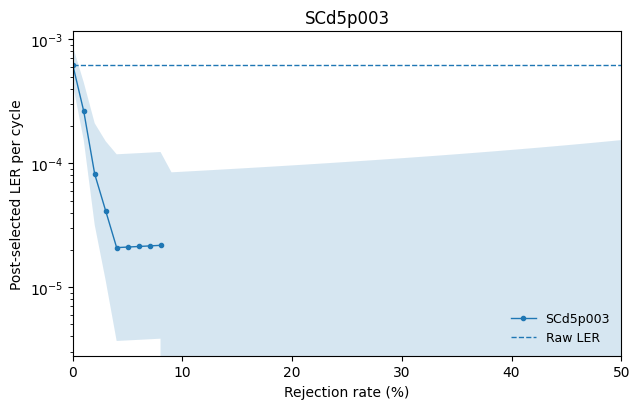

In [5]:
ax = mpnn4qec.plot_ler_curve(curve, rounds, label=model_name)
ax.set(title=model_name, xlim=(0, 50))
ax.figure.tight_layout()
plt.show()